# CabCancellation Project

  - Done by
            -> Anmol Singh
            -> Vanshdeep Singh
            -> Prerit Mehta
            -> Rishi Raj Gautam

  - Thank you so much, Sir, for your invaluable guidance and support throughout the Summer Training Program—it was a truly enriching experience.


### AIM -> In this Project we have to Create a model which identify the factors of the CabCancellation.

1:Here , is the column description of the data.
- id -> tells the booking_id of the customer.

- user_id -> the id of the customer(based on the mobile number).

- vehicle_model_id -> tells the vehicle id(like 12 , 28).

- travel_type_id -> tells the travel type taken via customer i.e:

      - 1=long distance
      - 2=point to point
      - 3=hourly rental.

- package_id -> tells the type of package , taken via customer.

      - 1=4hrs & 40kms
      - 2=8hrs & 80kms
      - 3=6hrs & 60kms
      - 4=10hrs & 100kms
      - 5=5hrs & 50kms
      - 6=3hrs & 30kms
      - 7=12hrs & 120kms

- from_area_id -> basically from which area customer is starting it's journey.Only applicable for point_to_point travel.

- to_area_id -> at which location the journey ends.Applicable for point_to_point travel only.

- from_city_id ->from which city customer is starting.Unique

- to_city_id -> to which city going.

- from_date -> at which time the journey starts.

- online_booking -> cab is online booked.

- mobile_site_booking -> cab is booked on mobile website.

- booking_created - time stamp of booking.

- from_lat - latitude of from area.

- from_long - longitude of from area.

- to_lat - latitude of to area.

- to_long - longitude of to area.

- Car_Cancellation - whether the booking was cancelled (1) or not (0) due to unavailability of a car.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
cab_df = pd.read_csv('/content/YourCabs.csv')

In [ ]:
cab_df.head()

,id,user_id,vehicle_model_id,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation
0,132512,22177,28,2,NaN,83.0,448.0,NaN,NaN,01-01-2013 02:00,0,0,01-01-2013 01:39,12.924150,77.672290,12.927320,77.635750,0
1,132513,21413,12,2,NaN,1010.0,540.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 02:25,12.966910,77.749350,12.927680,77.626640,0
2,132514,22178,12,2,NaN,1301.0,1034.0,NaN,NaN,01-01-2013 03:30,0,0,01-01-2013 03:08,12.937222,77.626915,13.047926,77.597766,0
3,132515,13034,12,2,NaN,768.0,398.0,NaN,NaN,01-01-2013 05:45,0,0,01-01-2013 04:39,12.989990,77.553320,12.971430,77.639140,0
4,132517,22180,12,2,NaN,1365.0,849.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 07:53,12.845653,77.677925,12.954340,77.600720,0


# let's see the data sample by sample

In [ ]:
cab_df.sample(5)

,id,user_id,vehicle_model_id,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation
25175,163503,1832,12,2,NaN,393.0,488.0,15.0,NaN,7/30/2013 19:15,0,0,7/30/2013 14:13,13.199560,77.706880,12.959979,77.647998,0
1126,133868,22902,12,3,1.0,293.0,NaN,NaN,NaN,1/14/2013 13:00,0,0,1/14/2013 10:26,12.849482,77.663187,NaN,NaN,0
21003,158343,40857,12,2,NaN,1010.0,1056.0,NaN,NaN,07-04-2013 22:15,0,0,07-04-2013 12:20,12.966910,77.749350,12.919199,77.609310,0
34646,175139,43442,12,3,3.0,455.0,NaN,NaN,NaN,9/24/2013 7:00,0,0,9/23/2013 18:49,12.999874,77.678120,NaN,NaN,0
23259,161138,28728,24,2,NaN,212.0,1010.0,NaN,NaN,7/18/2013 7:00,0,0,7/17/2013 20:41,12.994740,77.607970,12.966910,77.749350,0


In [ ]:
cab_df.shape

(43431, 18)

In [ ]:
cab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43431 entries, 0 to 43430
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   43431 non-null  int64  
 1   user_id              43431 non-null  int64  
 2   vehicle_model_id     43431 non-null  int64  
 3   travel_type_id       43431 non-null  int64  
 4   package_id           7550 non-null   float64
 5   from_area_id         43343 non-null  float64
 6   to_area_id           34293 non-null  float64
 7   from_city_id         16345 non-null  float64
 8   to_city_id           1588 non-null   float64
 9   from_date            43431 non-null  object 
 10  online_booking       43431 non-null  int64  
 11  mobile_site_booking  43431 non-null  int64  
 12  booking_created      43431 non-null  object 
 13  from_lat             43338 non-null  float64
 14  from_long            43338 non-null  float64
 15  to_lat               34293 non-null 

In [ ]:
cab_df.describe()

,id,user_id,vehicle_model_id,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,online_booking,mobile_site_booking,from_lat,from_long,to_lat,to_long,Car_Cancellation
count,43431.000000,43431.000000,43431.00000,43431.000000,7550.000000,43343.000000,34293.000000,16345.000000,1588.000000,43431.000000,43431.000000,43338.000000,43338.000000,34293.000000,34293.000000,43431.000000
mean,159206.473556,30739.198153,25.71723,2.137252,2.030066,714.544494,669.490917,14.915081,68.537783,0.351592,0.043241,12.982461,77.636255,13.026648,77.640595,0.072114
std,15442.386279,10996.476709,26.79825,0.437712,1.461756,419.883553,400.638225,1.165306,49.880732,0.477473,0.203402,0.085933,0.059391,0.113487,0.064045,0.258680
min,132512.000000,16.000000,1.00000,1.000000,1.000000,2.000000,2.000000,1.000000,4.000000,0.000000,0.000000,12.776630,77.386930,12.776630,77.386930,0.000000
25%,145778.000000,24614.000000,12.00000,2.000000,1.000000,393.000000,393.000000,15.000000,32.000000,0.000000,0.000000,12.926450,77.593661,12.951850,77.582030,0.000000
50%,159248.000000,31627.000000,12.00000,2.000000,2.000000,590.000000,541.000000,15.000000,49.000000,0.000000,0.000000,12.968887,77.635750,12.982750,77.645030,0.000000
75%,172578.500000,39167.000000,24.00000,2.000000,2.000000,1089.000000,1054.000000,15.000000,108.000000,1.000000,0.000000,13.007750,77.688900,13.199560,77.706880,0.000000
max,185941.000000,48730.000000,91.00000,3.000000,7.000000,1403.000000,1403.000000,31.000000,203.000000,1.000000,1.000000,13.366072,77.786420,13.366072,77.786420,1.000000


### Handle Missing Values

In [ ]:
cab_df.isnull().sum()

,0
id,0
user_id,0
vehicle_model_id,0
travel_type_id,0
package_id,35881
from_area_id,88
to_area_id,9138
from_city_id,27086
to_city_id,41843
from_date,0


In [ ]:
cab_df.isnull().sum()/len(cab_df)*100

,0
id,0.000000
user_id,0.000000
vehicle_model_id,0.000000
travel_type_id,0.000000
package_id,82.616104
from_area_id,0.202620
to_area_id,21.040271
from_city_id,62.365591
to_city_id,96.343626
from_date,0.000000


In [ ]:
cab_df['package_id'].sample(5)

,package_id
27452,NaN
22240,NaN
28384,NaN
31029,NaN
36567,1.0


# Now , in cab data columns like id,user_id(personal_info) or package_id , to_area_id , from_city_id , to_city_id which contains 82% of NAN. So , we can drop these columns.

In [ ]:
cab_df = cab_df.drop(['id' , 'user_id' , 'package_id' , 'to_area_id', 'from_city_id', 'to_city_id'] , axis=1)

In [ ]:
cab_df.shape

(43431, 12)

In [ ]:
cab_df.head()

,vehicle_model_id,travel_type_id,from_area_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation
0,28,2,83.0,01-01-2013 02:00,0,0,01-01-2013 01:39,12.924150,77.672290,12.927320,77.635750,0
1,12,2,1010.0,01-01-2013 09:00,0,0,01-01-2013 02:25,12.966910,77.749350,12.927680,77.626640,0
2,12,2,1301.0,01-01-2013 03:30,0,0,01-01-2013 03:08,12.937222,77.626915,13.047926,77.597766,0
3,12,2,768.0,01-01-2013 05:45,0,0,01-01-2013 04:39,12.989990,77.553320,12.971430,77.639140,0
4,12,2,1365.0,01-01-2013 09:00,0,0,01-01-2013 07:53,12.845653,77.677925,12.954340,77.600720,0


In [ ]:
cab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43431 entries, 0 to 43430
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vehicle_model_id     43431 non-null  int64  
 1   travel_type_id       43431 non-null  int64  
 2   from_area_id         43343 non-null  float64
 3   from_date            43431 non-null  object 
 4   online_booking       43431 non-null  int64  
 5   mobile_site_booking  43431 non-null  int64  
 6   booking_created      43431 non-null  object 
 7   from_lat             43338 non-null  float64
 8   from_long            43338 non-null  float64
 9   to_lat               34293 non-null  float64
 10  to_long              34293 non-null  float64
 11  Car_Cancellation     43431 non-null  int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 4.0+ MB


In [ ]:
cab_df['vehicle_model_id'].value_counts()

,count
vehicle_model_id,
12,31859
85,2407
89,2391
65,1912
28,1702
24,1494
87,565
90,312
23,297


In [ ]:
cab_df['vehicle_model_id'].value_counts(normalize=True)*100

,proportion
vehicle_model_id,
12,73.355437
85,5.542124
89,5.505284
65,4.402385
28,3.918860
24,3.439939
87,1.300914
90,0.718381
23,0.683843


# As , above we cab (12 is coming more than 73% times). So , create a seperate column for it (VMID_12) and drop (vehicle_model_it).

In [ ]:
cab_df['VMID_12'] = np.where(cab_df['vehicle_model_id'] == 12, 12, 0)

In [ ]:
cab_df = cab_df.drop(['vehicle_model_id'] , axis=1)

In [ ]:
cab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43431 entries, 0 to 43430
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   travel_type_id       43431 non-null  int64  
 1   from_area_id         43343 non-null  float64
 2   from_date            43431 non-null  object 
 3   online_booking       43431 non-null  int64  
 4   mobile_site_booking  43431 non-null  int64  
 5   booking_created      43431 non-null  object 
 6   from_lat             43338 non-null  float64
 7   from_long            43338 non-null  float64
 8   to_lat               34293 non-null  float64
 9   to_long              34293 non-null  float64
 10  Car_Cancellation     43431 non-null  int64  
 11  VMID_12              43431 non-null  int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 4.0+ MB


### Feature Engineering

# Taking out TimeStamp from(from_date and booking Created column)

In [ ]:
cab_df['from_date']

,from_date
0,01-01-2013 02:00
1,01-01-2013 09:00
2,01-01-2013 03:30
3,01-01-2013 05:45
4,01-01-2013 09:00
...,...
43426,11/24/2013 18:00
43427,11/26/2013 1:00
43428,11/24/2013 18:30
43429,11/24/2013 16:00


In [ ]:
cab_df.head(50)

,travel_type_id,from_area_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation,VMID_12
0,2,83.0,01-01-2013 02:00,0,0,01-01-2013 01:39,12.924150,77.672290,12.927320,77.635750,0,0
1,2,1010.0,01-01-2013 09:00,0,0,01-01-2013 02:25,12.966910,77.749350,12.927680,77.626640,0,12
2,2,1301.0,01-01-2013 03:30,0,0,01-01-2013 03:08,12.937222,77.626915,13.047926,77.597766,0,12
3,2,768.0,01-01-2013 05:45,0,0,01-01-2013 04:39,12.989990,77.553320,12.971430,77.639140,0,12
4,2,1365.0,01-01-2013 09:00,0,0,01-01-2013 07:53,12.845653,77.677925,12.954340,77.600720,0,12
5,2,1021.0,01-01-2013 22:30,0,0,01-01-2013 08:01,13.028530,77.546250,12.869805,77.653211,0,12
6,1,571.0,01-01-2013 09:45,0,0,01-01-2013 09:21,12.951850,77.696420,NaN,NaN,0,12
7,2,1192.0,01-01-2013 11:00,0,0,01-01-2013 09:39,12.976770,77.572700,12.880190,77.645580,0,12
8,3,448.0,01-01-2013 16:00,0,0,01-01-2013 09:44,12.927320,77.635750,NaN,NaN,0,0
9,2,516.0,01-01-2013 11:00,0,0,01-01-2013 09:49,13.005600,77.657990,12.902450,77.660810,0,12


In [ ]:
cab_df['from_date_dt'] = pd.to_datetime(cab_df['from_date'], errors='coerce', format='mixed').dt.strftime('%m/%d/%Y')
cab_df['from_time_tm'] = pd.to_datetime(cab_df['from_date'], errors='coerce', format='mixed').dt.strftime('%H:%M')
cab_df['booking_created_dt'] = pd.to_datetime(cab_df['booking_created'], errors='coerce', format='mixed').dt.strftime('%m/%d/%Y')
cab_df['booking_created_tm'] = pd.to_datetime(cab_df['booking_created'], errors='coerce', format='mixed').dt.strftime('%H:%M')

In [ ]:
cab_df['from_date_day'] = pd.to_datetime(cab_df['from_date_dt']).dt.day_name()
cab_df['booking_created_day'] = pd.to_datetime(cab_df['booking_created_dt']).dt.day_name()
cab_df['from_date_month'] = pd.to_datetime(cab_df['from_date_dt']).dt.month_name()
cab_df['booking_created_month'] = pd.to_datetime(cab_df['booking_created_dt']).dt.month_name()
cab_df['from_date_week'] = np.where((cab_df['from_date_day']=='Saturday') | (cab_df['from_date_day']=='Sunday'),'Weekend','Weekday')
cab_df['booking_created_week'] = np.where((cab_df['booking_created_day']=='Saturday') | (cab_df['booking_created_day']=='Sunday'),'Weekend','Weekday')

In [ ]:
cond = [(pd.to_datetime(cab_df['from_time_tm']).dt.hour.between(5, 8)),
        (pd.to_datetime(cab_df['from_time_tm']).dt.hour.between(9, 12)),
        (pd.to_datetime(cab_df['from_time_tm']).dt.hour.between(13, 16)),
        (pd.to_datetime(cab_df['from_time_tm']).dt.hour.between(17, 20)),
        ((pd.to_datetime(cab_df['from_time_tm']).dt.hour.between(21, 24)) | (pd.to_datetime(cab_df['from_time_tm']).dt.hour==0)),
        (pd.to_datetime(cab_df['from_time_tm']).dt.hour.between(1, 4))]
values = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
cab_df['from_date_session'] = np.select(cond,values, default=None)

In [ ]:
cond = [(pd.to_datetime(cab_df['booking_created_tm']).dt.hour.between(5, 8)),
        (pd.to_datetime(cab_df['booking_created_tm']).dt.hour.between(9, 12)),
        (pd.to_datetime(cab_df['booking_created_tm']).dt.hour.between(13, 16)),
        (pd.to_datetime(cab_df['booking_created_tm']).dt.hour.between(17, 20)),
        ((pd.to_datetime(cab_df['booking_created_tm']).dt.hour.between(21, 24)) | (pd.to_datetime(cab_df['booking_created_tm']).dt.hour==0)),
        (pd.to_datetime(cab_df['booking_created_tm']).dt.hour.between(1, 4))]
values = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
cab_df['booking_created_session'] = np.select(cond,values, default=None)

In [ ]:
cab_df['time_diff'] = (pd.to_datetime(cab_df['from_date'], errors='coerce', format='mixed') - pd.to_datetime(cab_df['booking_created'], errors='coerce', format='mixed')).dt.total_seconds() / 60

In [ ]:
cab_df[cab_df['time_diff'] < 0].head()

,travel_type_id,from_area_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,...,booking_created_tm,from_date_day,booking_created_day,from_date_month,booking_created_month,from_date_week,booking_created_week,from_date_session,booking_created_session,time_diff
1763,3,1298.0,1/20/2013 14:15,0,0,1/20/2013 15:01,12.879678,77.646355,NaN,NaN,...,15:01,Sunday,Sunday,January,January,Weekend,Weekend,Afternoon,Afternoon,-46.0
2990,3,393.0,02-01-2013 09:45,0,0,02-01-2013 13:18,13.199560,77.706880,NaN,NaN,...,13:18,Friday,Friday,February,February,Weekday,Weekday,Morning,Afternoon,-213.0
4228,3,571.0,2/13/2013 18:00,0,0,2/13/2013 18:29,12.951850,77.696420,NaN,NaN,...,18:29,Wednesday,Wednesday,February,February,Weekday,Weekday,Evening,Evening,-29.0
5303,3,1068.0,2/23/2013 18:00,0,0,2/23/2013 18:03,13.044009,77.606805,NaN,NaN,...,18:03,Saturday,Saturday,February,February,Weekend,Weekend,Evening,Evening,-3.0
6106,3,1010.0,03-04-2013 00:30,0,0,03-04-2013 02:00,12.966910,77.749350,NaN,NaN,...,02:00,Monday,Monday,March,March,Weekday,Weekday,Night,Late Night,-90.0


In [ ]:
cab_df = cab_df.drop(['from_date' , 'booking_created'] , axis=1)

In [ ]:
cab_df = cab_df.drop(['from_date_dt','from_time_tm','booking_created_dt','booking_created_tm'],axis=1)

In [ ]:
cab_df

,travel_type_id,from_area_id,online_booking,mobile_site_booking,from_lat,from_long,to_lat,to_long,Car_Cancellation,VMID_12,from_date_day,booking_created_day,from_date_month,booking_created_month,from_date_week,booking_created_week,from_date_session,booking_created_session,time_diff
0,2,83.0,0,0,12.924150,77.672290,12.927320,77.635750,0,0,Tuesday,Tuesday,January,January,Weekday,Weekday,Late Night,Late Night,21.0
1,2,1010.0,0,0,12.966910,77.749350,12.927680,77.626640,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Morning,Late Night,395.0
2,2,1301.0,0,0,12.937222,77.626915,13.047926,77.597766,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Late Night,Late Night,22.0
3,2,768.0,0,0,12.989990,77.553320,12.971430,77.639140,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Early Morning,Late Night,66.0
4,2,1365.0,0,0,12.845653,77.677925,12.954340,77.600720,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Morning,Early Morning,67.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43426,2,1147.0,1,0,13.030640,77.649100,12.952780,77.590880,0,12,Sunday,Sunday,November,November,Weekend,Weekend,Evening,Afternoon,215.0
43427,2,393.0,1,0,13.199560,77.706880,13.017436,77.644580,0,12,Tuesday,Sunday,November,November,Weekday,Weekend,Late Night,Afternoon,2070.0
43428,3,974.0,0,0,13.075570,77.559040,NaN,NaN,0,12,Sunday,Sunday,November,November,Weekend,Weekend,Evening,Afternoon,235.0
43429,2,1263.0,0,0,12.968970,77.594560,12.938230,77.622890,0,0,Sunday,Sunday,November,November,Weekend,Weekend,Afternoon,Afternoon,77.0


In [ ]:
cab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43431 entries, 0 to 43430
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   travel_type_id           43431 non-null  int64  
 1   from_area_id             43343 non-null  float64
 2   online_booking           43431 non-null  int64  
 3   mobile_site_booking      43431 non-null  int64  
 4   from_lat                 43338 non-null  float64
 5   from_long                43338 non-null  float64
 6   to_lat                   34293 non-null  float64
 7   to_long                  34293 non-null  float64
 8   Car_Cancellation         43431 non-null  int64  
 9   VMID_12                  43431 non-null  int64  
 10  from_date_day            43431 non-null  object 
 11  booking_created_day      43431 non-null  object 
 12  from_date_month          43431 non-null  object 
 13  booking_created_month    43431 non-null  object 
 14  from_date_week        

In [ ]:
cab_df = cab_df.drop(['from_lat' , 'from_long' , 'to_lat' , 'to_long'] , axis=1)

In [ ]:
cab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43431 entries, 0 to 43430
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   travel_type_id           43431 non-null  int64  
 1   from_area_id             43343 non-null  float64
 2   online_booking           43431 non-null  int64  
 3   mobile_site_booking      43431 non-null  int64  
 4   Car_Cancellation         43431 non-null  int64  
 5   VMID_12                  43431 non-null  int64  
 6   from_date_day            43431 non-null  object 
 7   booking_created_day      43431 non-null  object 
 8   from_date_month          43431 non-null  object 
 9   booking_created_month    43431 non-null  object 
 10  from_date_week           43431 non-null  object 
 11  booking_created_week     43431 non-null  object 
 12  from_date_session        43431 non-null  object 
 13  booking_created_session  43431 non-null  object 
 14  time_diff             

# Converting to low,medium,high Cancellation area via from_area_id

In [ ]:
cab_df['from_area_id'] = round(cab_df.groupby('from_area_id')['Car_Cancellation'].mean(), 2)
cab_df['from_area_id'].replace(np.nan, 0, inplace=True)

In [ ]:
cond = [(cab_df['from_area_id'].astype('float').between(0,0.33)),
        (cab_df['from_area_id'].astype('float').between(0.34,0.66)),
        (cab_df['from_area_id'].astype('float').between(0.67,1.0))]
values = ['Low Cancellation','Medium Cancellation','High Cancellation']
cab_df['from_area_id'] = np.select(cond,values, default='Unknown')

In [ ]:
cab_df

,travel_type_id,from_area_id,online_booking,mobile_site_booking,Car_Cancellation,VMID_12,from_date_day,booking_created_day,from_date_month,booking_created_month,from_date_week,booking_created_week,from_date_session,booking_created_session,time_diff
0,2,Low Cancellation,0,0,0,0,Tuesday,Tuesday,January,January,Weekday,Weekday,Late Night,Late Night,21.0
1,2,Low Cancellation,0,0,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Morning,Late Night,395.0
2,2,Low Cancellation,0,0,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Late Night,Late Night,22.0
3,2,Low Cancellation,0,0,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Early Morning,Late Night,66.0
4,2,Low Cancellation,0,0,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Morning,Early Morning,67.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43426,2,Low Cancellation,1,0,0,12,Sunday,Sunday,November,November,Weekend,Weekend,Evening,Afternoon,215.0
43427,2,Low Cancellation,1,0,0,12,Tuesday,Sunday,November,November,Weekday,Weekend,Late Night,Afternoon,2070.0
43428,3,Low Cancellation,0,0,0,12,Sunday,Sunday,November,November,Weekend,Weekend,Evening,Afternoon,235.0
43429,2,Low Cancellation,0,0,0,0,Sunday,Sunday,November,November,Weekend,Weekend,Afternoon,Afternoon,77.0


In [ ]:
cab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43431 entries, 0 to 43430
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   travel_type_id           43431 non-null  int64  
 1   from_area_id             43431 non-null  object 
 2   online_booking           43431 non-null  int64  
 3   mobile_site_booking      43431 non-null  int64  
 4   Car_Cancellation         43431 non-null  int64  
 5   VMID_12                  43431 non-null  int64  
 6   from_date_day            43431 non-null  object 
 7   booking_created_day      43431 non-null  object 
 8   from_date_month          43431 non-null  object 
 9   booking_created_month    43431 non-null  object 
 10  from_date_week           43431 non-null  object 
 11  booking_created_week     43431 non-null  object 
 12  from_date_session        43431 non-null  object 
 13  booking_created_session  43431 non-null  object 
 14  time_diff             

# Data Visualization

In [ ]:
cab_df.head()

,travel_type_id,from_area_id,online_booking,mobile_site_booking,Car_Cancellation,VMID_12,from_date_day,booking_created_day,from_date_month,booking_created_month,from_date_week,booking_created_week,from_date_session,booking_created_session,time_diff
0,2,Low Cancellation,0,0,0,0,Tuesday,Tuesday,January,January,Weekday,Weekday,Late Night,Late Night,21.0
1,2,Low Cancellation,0,0,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Morning,Late Night,395.0
2,2,Low Cancellation,0,0,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Late Night,Late Night,22.0
3,2,Low Cancellation,0,0,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Early Morning,Late Night,66.0
4,2,Low Cancellation,0,0,0,12,Tuesday,Tuesday,January,January,Weekday,Weekday,Morning,Early Morning,67.0


In [ ]:
cab_df['from_area_id'].value_counts()

,count
from_area_id,
Low Cancellation,43415
Medium Cancellation,11
High Cancellation,5


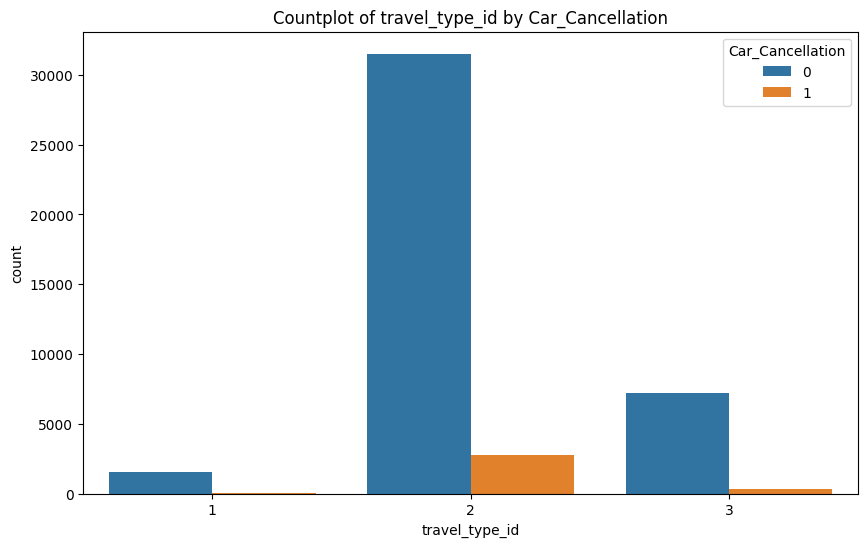

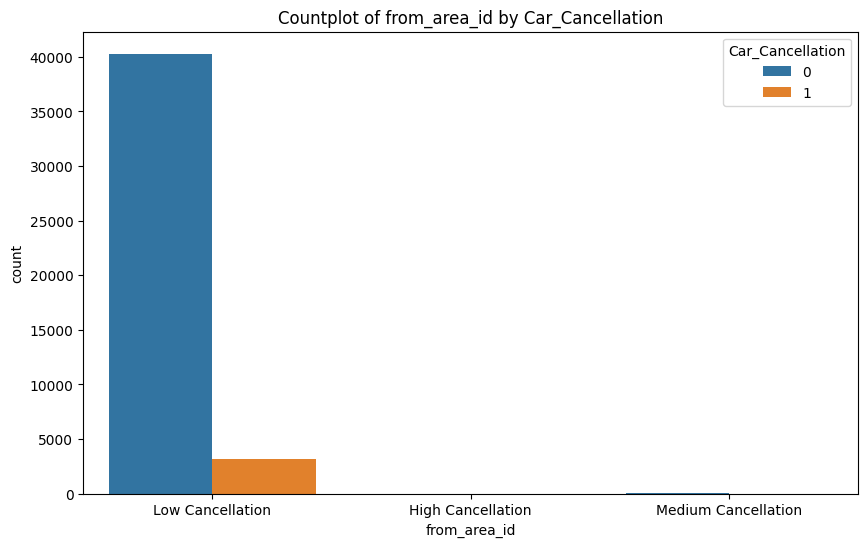

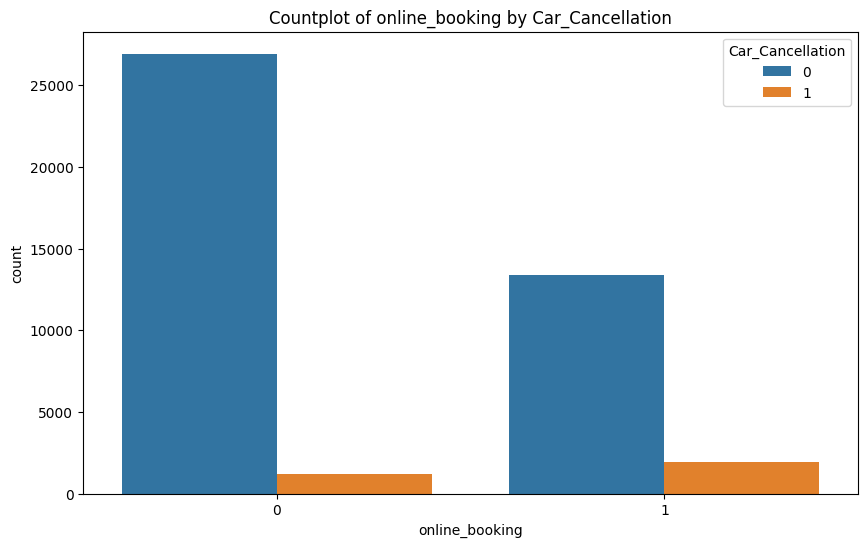

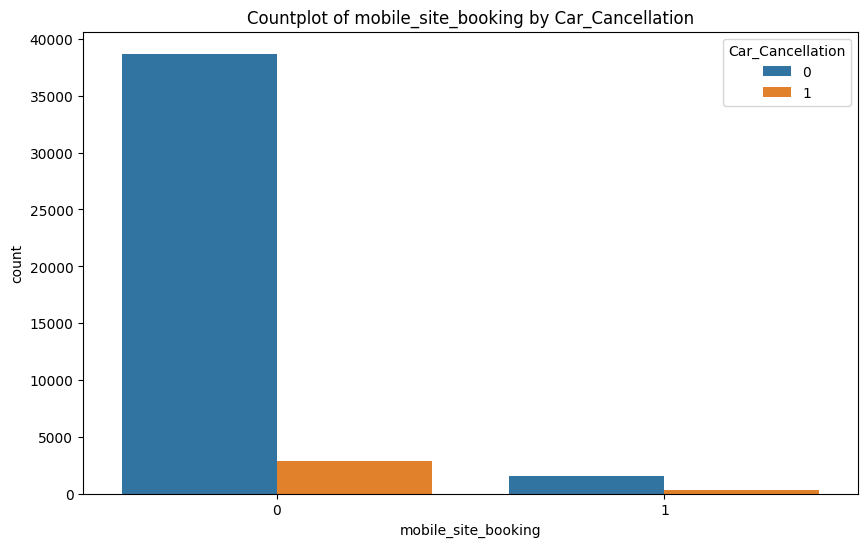

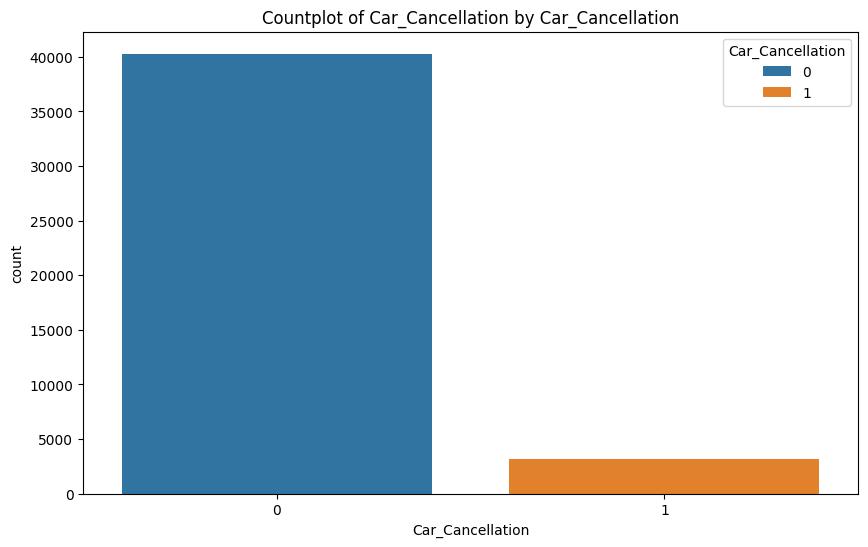

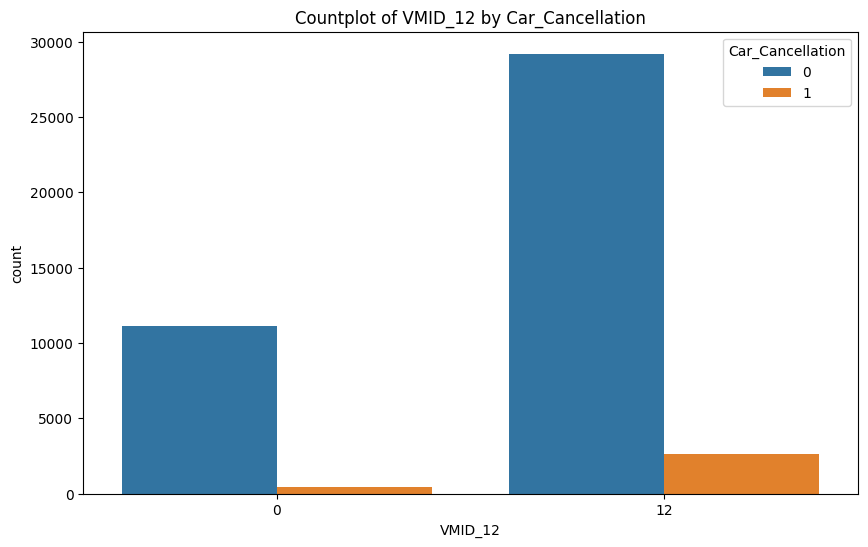

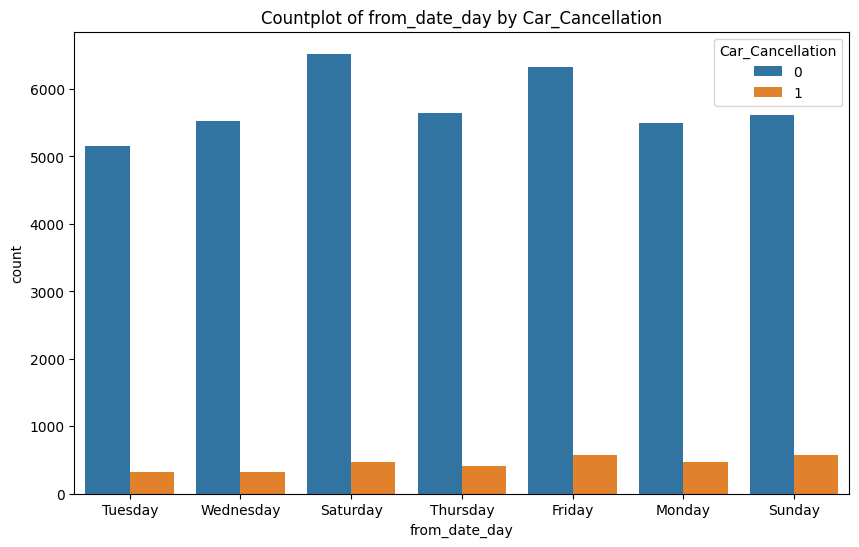

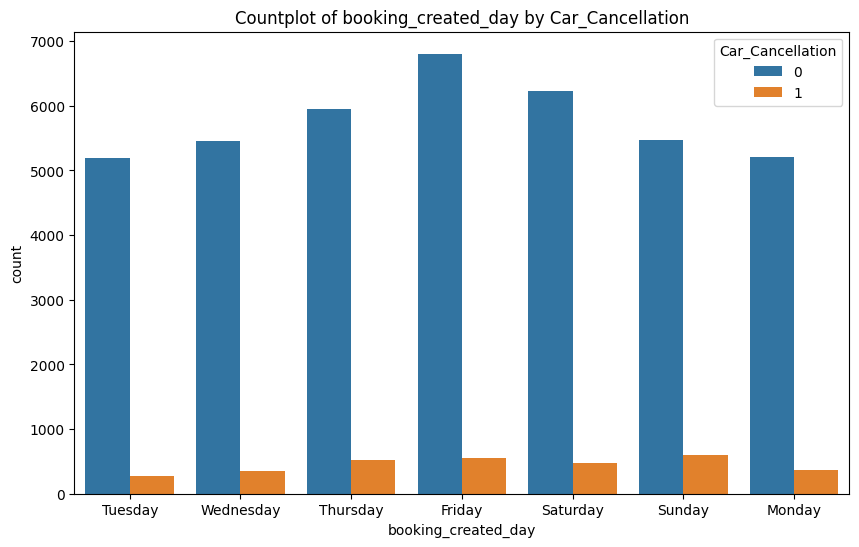

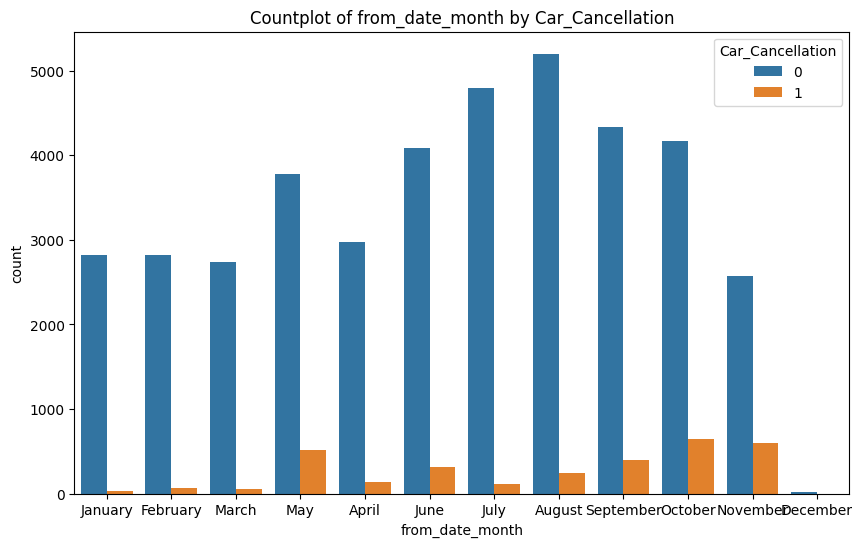

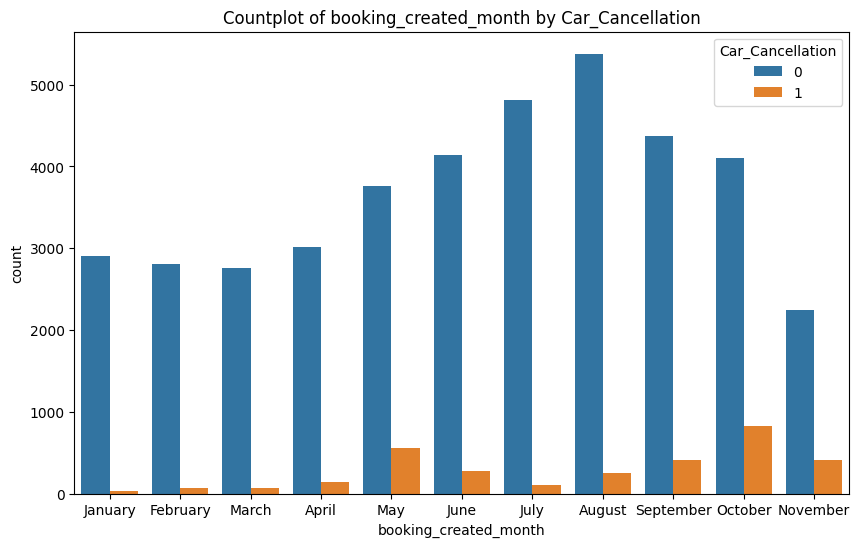

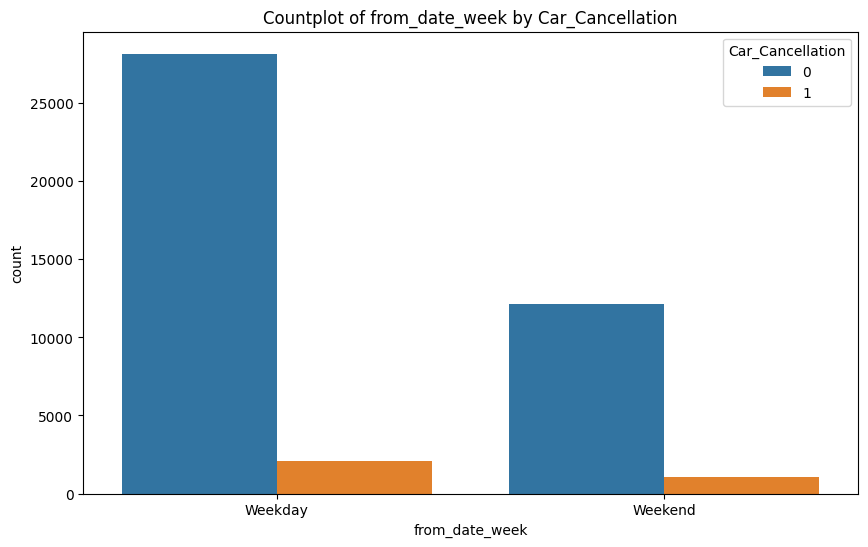

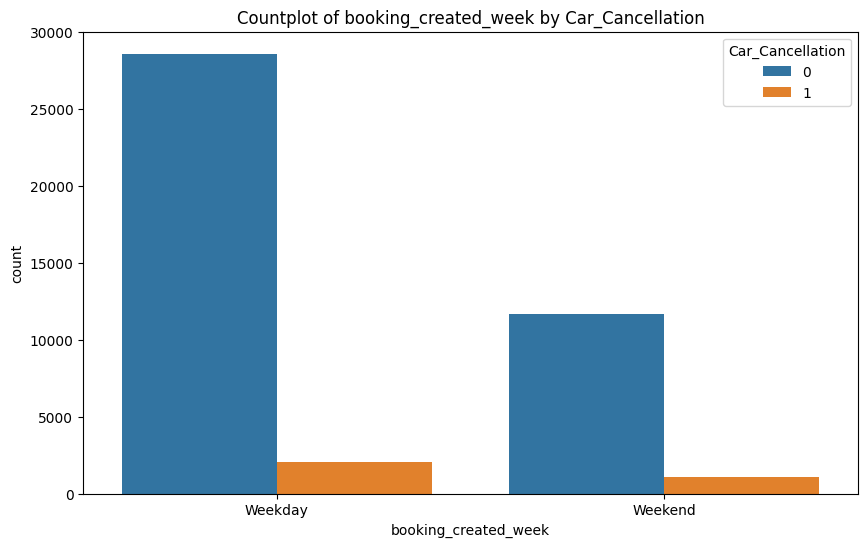

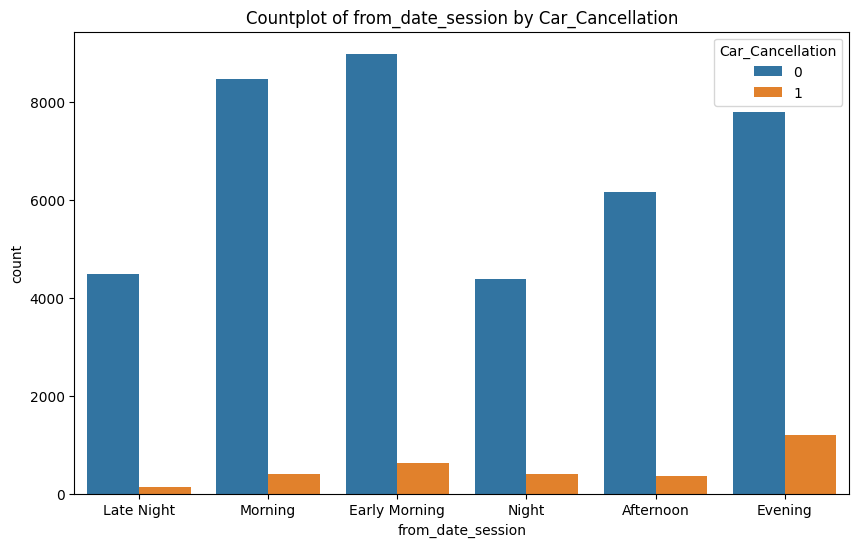

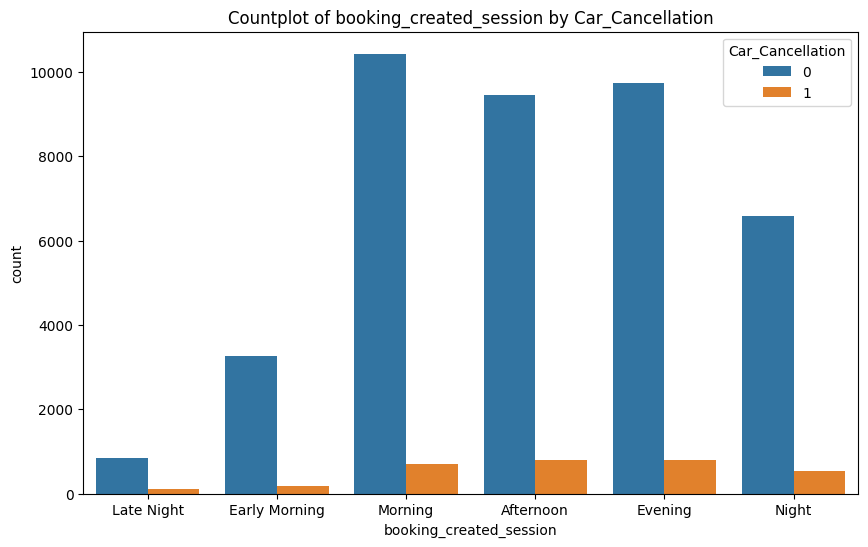

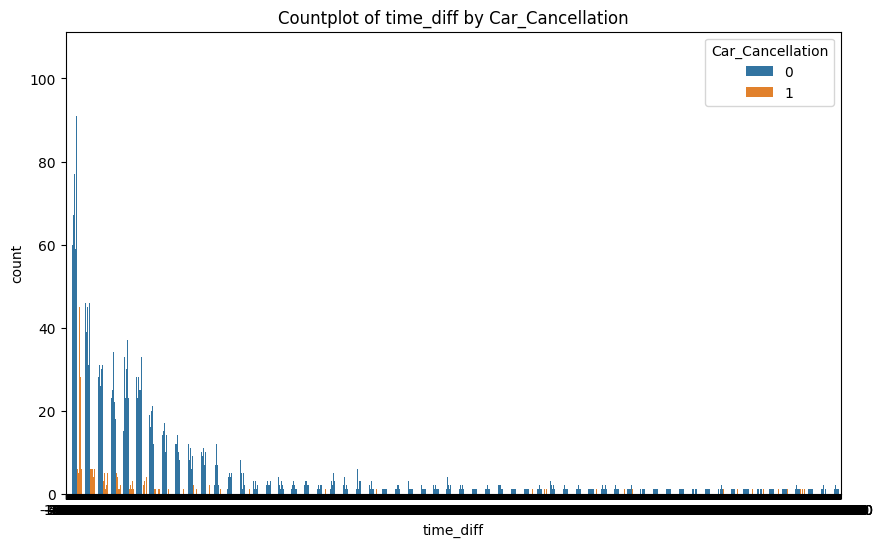

In [ ]:
def plots(column):
  plt.figure(figsize=(10, 6))
  sns.countplot(data=cab_df, x=column, hue='Car_Cancellation')
  plt.title(f'Countplot of {column} by Car_Cancellation')
  plt.show()

for column in list(cab_df.columns)[0:]:
  plots(column)

In [ ]:
cab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43431 entries, 0 to 43430
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   travel_type_id           43431 non-null  int64  
 1   from_area_id             43431 non-null  object 
 2   online_booking           43431 non-null  int64  
 3   mobile_site_booking      43431 non-null  int64  
 4   Car_Cancellation         43431 non-null  int64  
 5   VMID_12                  43431 non-null  int64  
 6   from_date_day            43431 non-null  object 
 7   booking_created_day      43431 non-null  object 
 8   from_date_month          43431 non-null  object 
 9   booking_created_month    43431 non-null  object 
 10  from_date_week           43431 non-null  object 
 11  booking_created_week     43431 non-null  object 
 12  from_date_session        43431 non-null  object 
 13  booking_created_session  43431 non-null  object 
 14  time_diff             

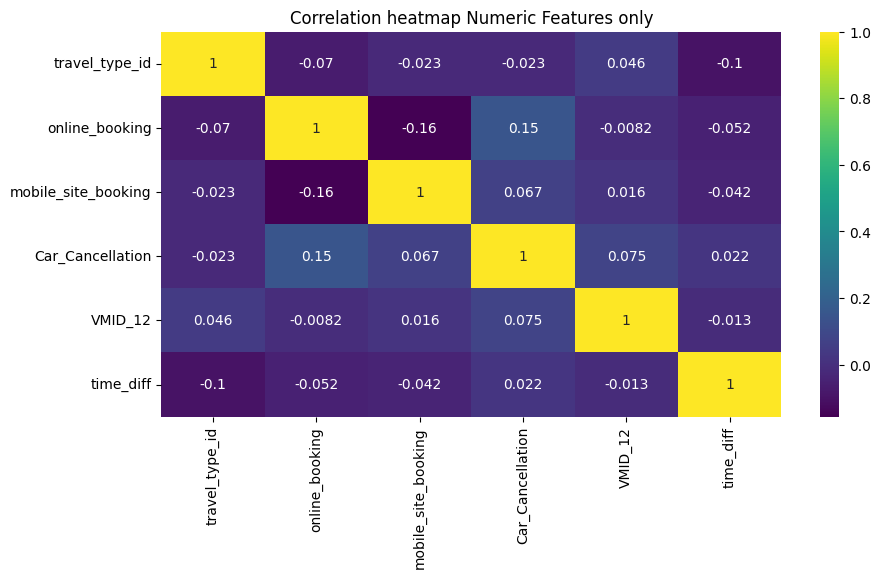

In [ ]:
#correlation heatmap
numeric_df = cab_df.select_dtypes(include=['int64' , 'float64'])
plt.figure(figsize=(10,5))
sns.heatmap(numeric_df.corr() , annot=True , cmap='viridis')
plt.title("Correlation heatmap Numeric Features only")
plt.show()

<Figure size 1000x500 with 0 Axes>

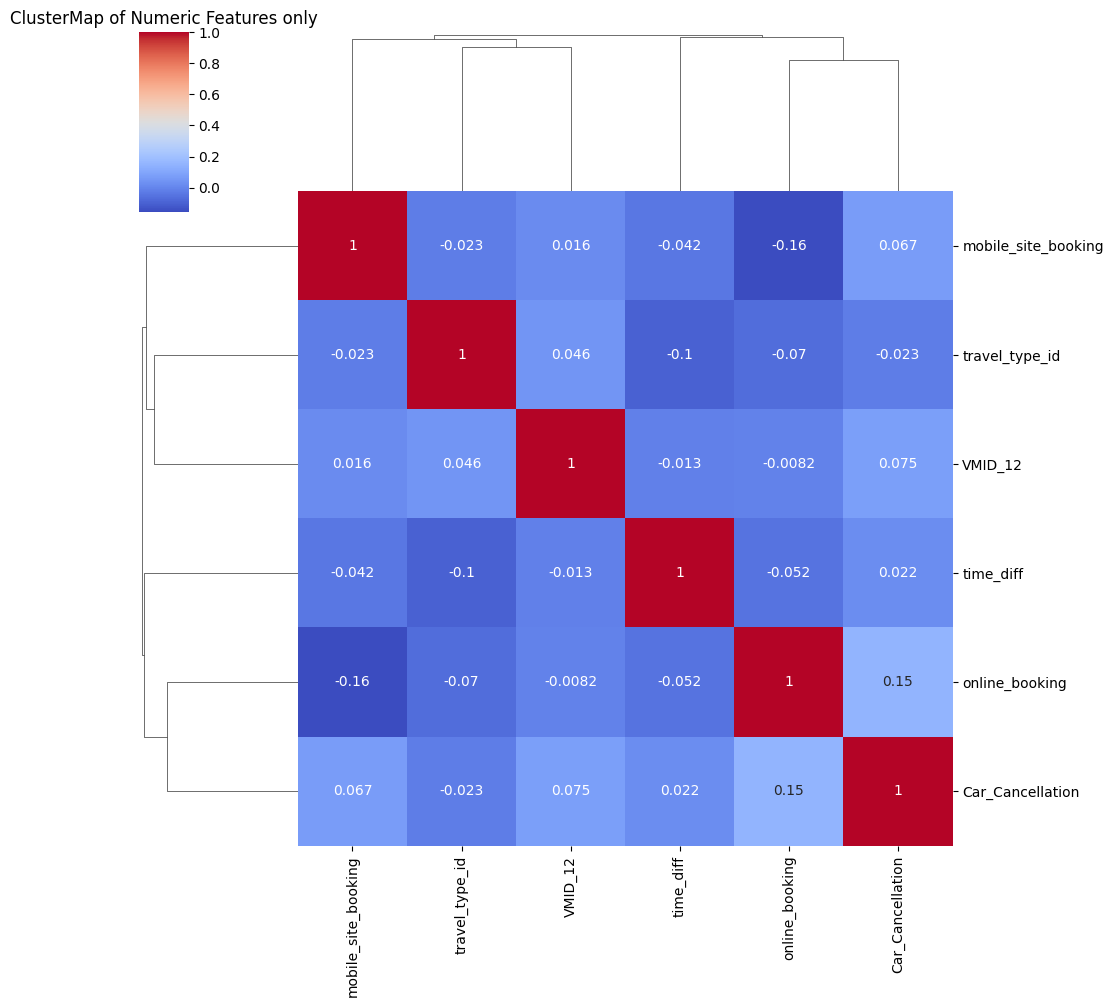

In [85]:
#advanced heatmap -> clustermap(shows the cluster(or correlation))
numeric_df = cab_df.select_dtypes(include=['int64' , 'float64'])
plt.figure(figsize=(10,5))
sns.clustermap(numeric_df.corr() , annot=True , cmap='coolwarm')
plt.title("ClusterMap of Numeric Features only")
plt.show()

In [ ]:
cab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43431 entries, 0 to 43430
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   travel_type_id           43431 non-null  int64  
 1   from_area_id             43431 non-null  object 
 2   online_booking           43431 non-null  int64  
 3   mobile_site_booking      43431 non-null  int64  
 4   Car_Cancellation         43431 non-null  int64  
 5   VMID_12                  43431 non-null  int64  
 6   from_date_day            43431 non-null  object 
 7   booking_created_day      43431 non-null  object 
 8   from_date_month          43431 non-null  object 
 9   booking_created_month    43431 non-null  object 
 10  from_date_week           43431 non-null  object 
 11  booking_created_week     43431 non-null  object 
 12  from_date_session        43431 non-null  object 
 13  booking_created_session  43431 non-null  object 
 14  time_diff             

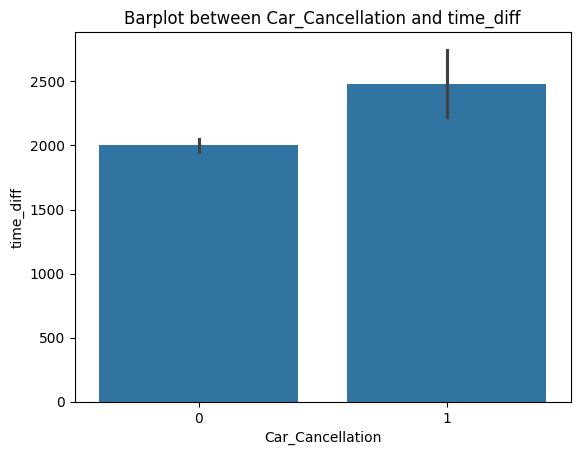

In [91]:
sns.barplot(data=cab_df , x='Car_Cancellation' , y='time_diff')
plt.title("Barplot between Car_Cancellation and time_diff")
plt.show()

# Dividing the data into numerical and categorical values:

In [ ]:
num = cab_df.select_dtypes(include='number')
char = cab_df.select_dtypes(include='object')

In [ ]:
num.head()

,travel_type_id,online_booking,mobile_site_booking,Car_Cancellation,VMID_12,time_diff
0,2,0,0,0,0,21.0
1,2,0,0,0,12,395.0
2,2,0,0,0,12,22.0
3,2,0,0,0,12,66.0
4,2,0,0,0,12,67.0


In [ ]:
char.head()

,from_area_id,from_date_day,booking_created_day,from_date_month,booking_created_month,from_date_week,booking_created_week,from_date_session,booking_created_session
0,Low Cancellation,Tuesday,Tuesday,January,January,Weekday,Weekday,Late Night,Late Night
1,Low Cancellation,Tuesday,Tuesday,January,January,Weekday,Weekday,Morning,Late Night
2,Low Cancellation,Tuesday,Tuesday,January,January,Weekday,Weekday,Late Night,Late Night
3,Low Cancellation,Tuesday,Tuesday,January,January,Weekday,Weekday,Early Morning,Late Night
4,Low Cancellation,Tuesday,Tuesday,January,January,Weekday,Weekday,Morning,Early Morning


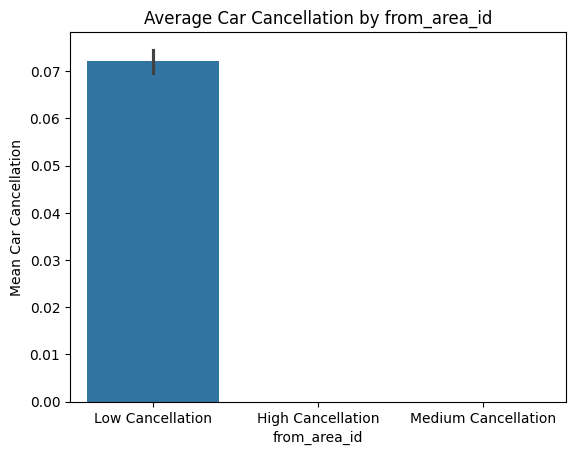

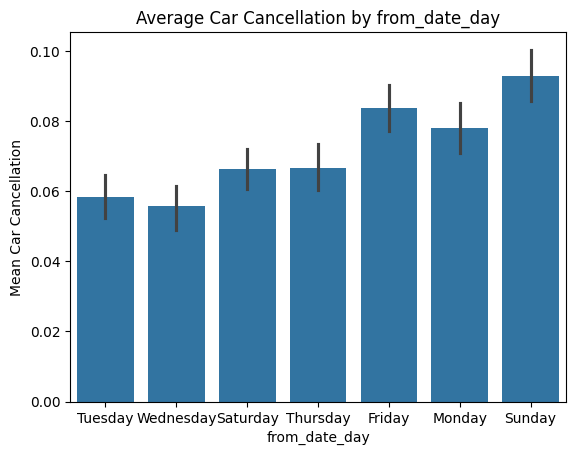

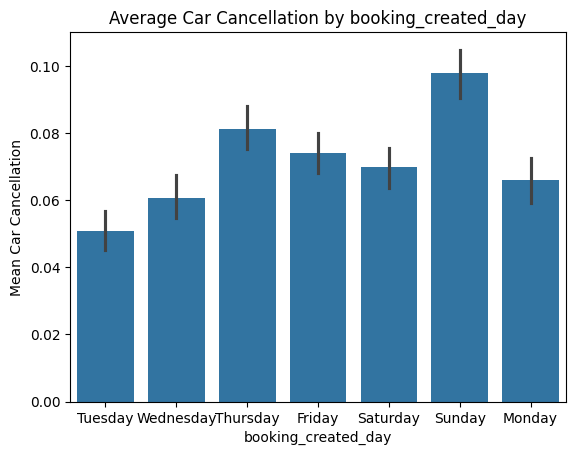

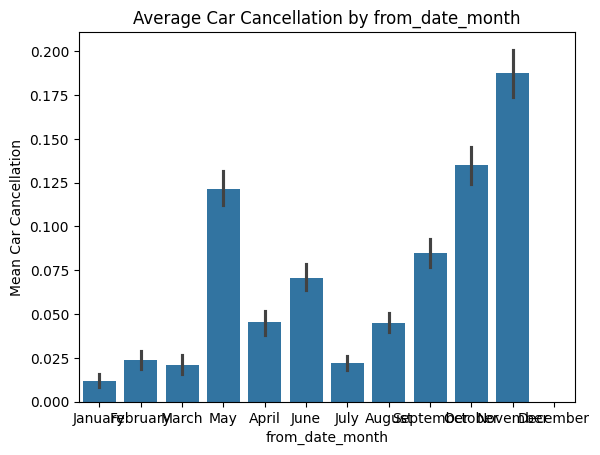

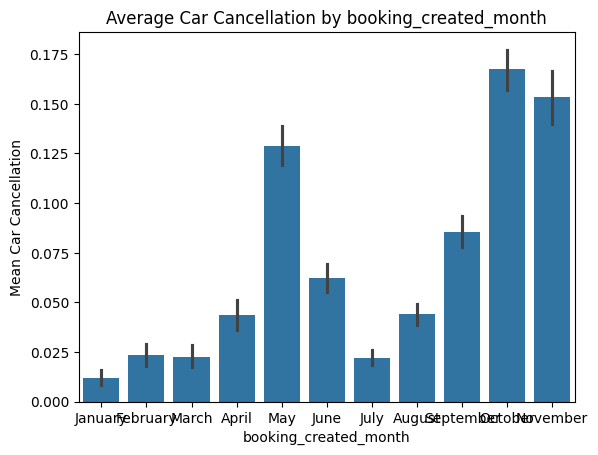

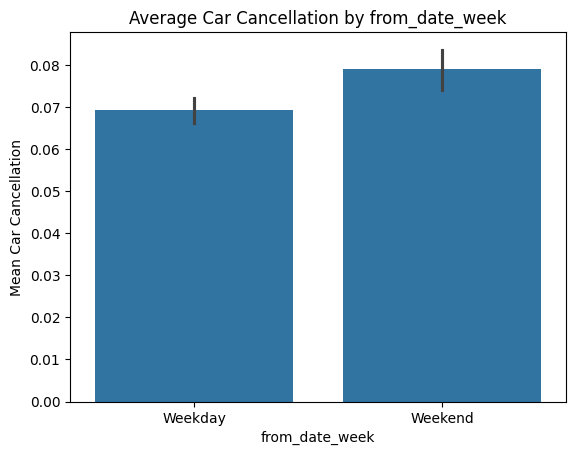

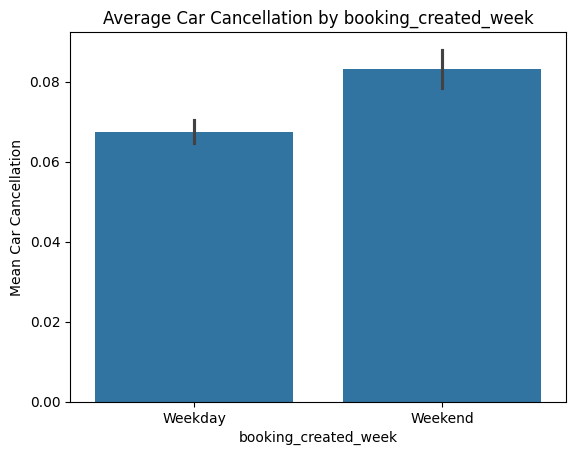

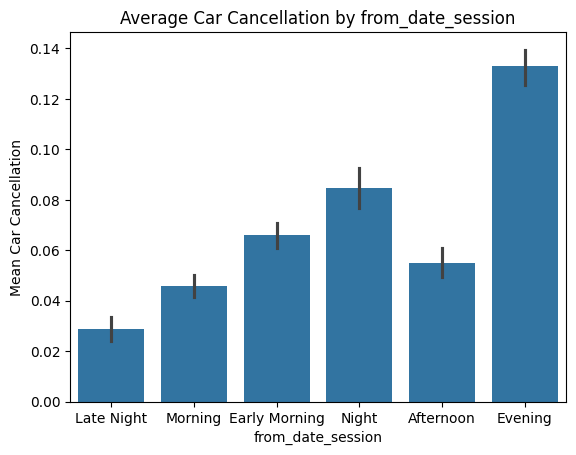

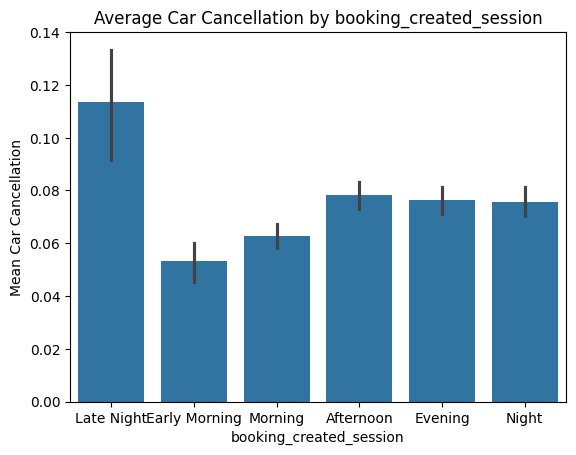

In [ ]:
X_char_merged = pd.concat([char,cab_df['Car_Cancellation']],axis=1,join='inner')

from numpy import mean
for col in char.columns:
  plt.figure()
  #plotting barplot for to show mean of Car_Cancellation per category:
  #now we can how the Car_Cancellation is varying with different columns:
  sns.barplot(x=col, y='Car_Cancellation', data=X_char_merged,estimator=mean)
  plt.title(f'Average Car Cancellation by {col}')
  plt.ylabel('Mean Car Cancellation')
plt.show()

# Apply One Hot-Encoding on Categorical Variables:

In [ ]:
x_char_dummy = pd.get_dummies(char , drop_first=True)
#dropping the first category of each column to avoid multicollinearity

In [ ]:
x_char_dummy

,from_area_id_Low Cancellation,from_area_id_Medium Cancellation,from_date_day_Monday,from_date_day_Saturday,from_date_day_Sunday,from_date_day_Thursday,from_date_day_Tuesday,from_date_day_Wednesday,booking_created_day_Monday,booking_created_day_Saturday,...,from_date_session_Early Morning,from_date_session_Evening,from_date_session_Late Night,from_date_session_Morning,from_date_session_Night,booking_created_session_Early Morning,booking_created_session_Evening,booking_created_session_Late Night,booking_created_session_Morning,booking_created_session_Night
0,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
1,True,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
2,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,True,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
4,True,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43426,True,False,False,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
43427,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
43428,True,False,False,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
43429,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
all_dta = pd.concat([num , x_char_dummy] , axis=1 , join='inner')

In [ ]:
all_dta.head()

,travel_type_id,online_booking,mobile_site_booking,Car_Cancellation,VMID_12,time_diff,from_area_id_Low Cancellation,from_area_id_Medium Cancellation,from_date_day_Monday,from_date_day_Saturday,...,from_date_session_Early Morning,from_date_session_Evening,from_date_session_Late Night,from_date_session_Morning,from_date_session_Night,booking_created_session_Early Morning,booking_created_session_Evening,booking_created_session_Late Night,booking_created_session_Morning,booking_created_session_Night
0,2,0,0,0,0,21.0,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
1,2,0,0,0,12,395.0,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
2,2,0,0,0,12,22.0,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,2,0,0,0,12,66.0,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
4,2,0,0,0,12,67.0,True,False,False,False,...,False,False,False,True,False,True,False,False,False,False


In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , accuracy_score , precision_score , recall_score , roc_auc_score , f1_score

In [94]:
target = cab_df['Car_Cancellation']

In [95]:
X_train , X_test , y_train , y_test = train_test_split(all_dta , target , test_size=0.2 , random_state=2)

In [96]:
logr = LogisticRegression()

In [97]:
#train the model:
logr.fit(X_train , y_train)

LogisticRegression()

In [98]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(LogisticRegression() , X_train , y_train , cv=5))

np.float64(0.9991077852928478)

In [99]:
y_pred = logr.predict(X_test)
print('accuracy_score is: ' , accuracy_score(y_test , y_pred))
print('precision is: ' , precision_score(y_test , y_pred))
print('recall is: ' , recall_score(y_test , y_pred))
print('f1_score is: ' , f1_score(y_test , y_pred))

accuracy_score is:  0.9990790836882698
precision is:  1.0
recall is:  0.9866666666666667
f1_score is:  0.9932885906040269


- TN(True Negative -> Model predicted Cab->Not cancel ->and it was NotCancelled
- FN(False Negative -> Model predicted NotCancelled ->but actually cancelled
- FP(False Positive -> Model predicted Cancel -> actual notCancelled
- TP(True Positive -> Model predicted Cancel -> actual Cancelled

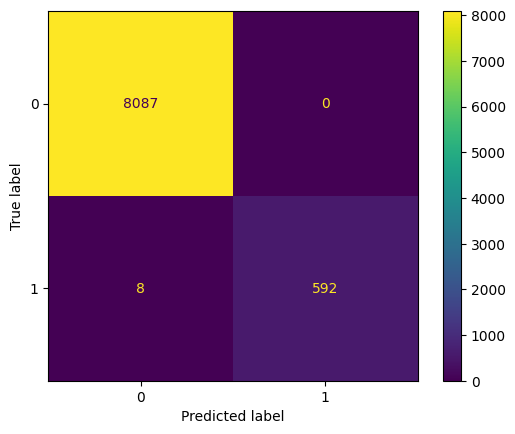

In [109]:
from sklearn.metrics import ConfusionMatrixDisplay
#confusionmatrix can also be print like this:
ConfusionMatrixDisplay.from_estimator(logr , X_test , y_test)
#ConfusionMatrixDisplay.from_estimator(logr , X_test , y_test , normalize='true')

In [110]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(criterion='gini' , random_state=4)

# Applying GridSearchCV

In [117]:
from sklearn.model_selection import GridSearchCV
param_dist = {'max_depth': [3, 5, 6, 7], 'min_samples_split': [50, 100, 150, 200, 250]}
#n_jobs ->used for how many multiple models you want to train(i.e parallel processing)[or how many CPU_Core you are using]
gscv_dtc = GridSearchCV(dtc , cv=10, param_grid=param_dist, n_jobs=-1)
gscv_dtc.fit(X_train,y_train)

GridSearchCV(cv=10,
             estimator=DecisionTreeClassifier(max_depth=4, min_samples_split=50,
                                              random_state=4),
             n_jobs=-1,
             param_grid={'max_depth': [3, 5, 6, 7],
                         'min_samples_split': [50, 100, 150, 200, 250]})

In [118]:
#now checking the best params for the decisionTree
gscv_dtc.best_params_

{'max_depth': 3, 'min_samples_split': 50}

In [119]:
dtc = DecisionTreeClassifier(criterion='gini' , random_state=4 , max_depth=4 , min_samples_split=50)
dtc.fit(X_train , y_train)

DecisionTreeClassifier(max_depth=4, min_samples_split=50, random_state=4)

In [120]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(DecisionTreeClassifier() , X_train , y_train , cv=5))

np.float64(1.0)

In [121]:
y_pred_dtc = dtc.predict(X_test)
print('accuracy_score is: ' , accuracy_score(y_test , y_pred_dtc))
print('precision is: ' , precision_score(y_test , y_pred_dtc))
print('recall is: ' , recall_score(y_test , y_pred_dtc))
print('f1_score is: ' , f1_score(y_test , y_pred_dtc))

accuracy_score is:  1.0
precision is:  1.0
recall is:  1.0
f1_score is:  1.0


[Text(0.5, 0.75, 'x[3] <= 0.5\ngini = 0.135\nsamples = 34744\nvalue = [32212, 2532]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 32212\nvalue = [32212, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 2532\nvalue = [0, 2532]'),
 Text(0.625, 0.5, '  False')]

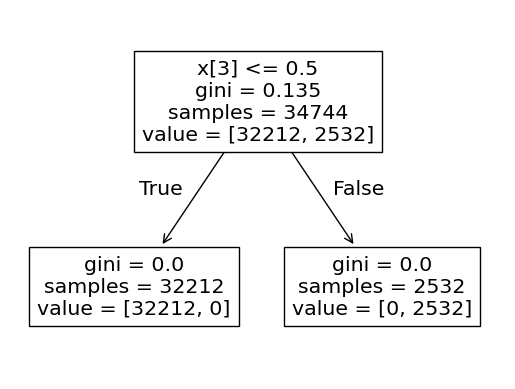

In [122]:
from sklearn.tree import plot_tree
plot_tree(dtc)

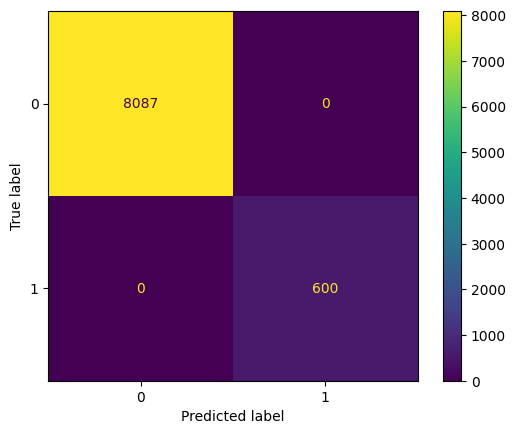

In [123]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(dtc , X_test , y_test)

In [124]:
from sklearn.ensemble import RandomForestClassifier

In [125]:
rfc = RandomForestClassifier(criterion='gini' , random_state=4)

In [126]:
rfc.fit(X_train , y_train)

RandomForestClassifier(random_state=4)

In [128]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(RandomForestClassifier() , X_train , y_train , cv=5))

np.float64(1.0)

In [129]:
y_pred_rf = rfc.predict(X_test)
print('accuracy_score is: ' , accuracy_score(y_test , y_pred_rf))
print('precision is: ' , precision_score(y_test , y_pred_rf))
print('recall is: ' , recall_score(y_test , y_pred_rf))
print('f1_score is: ' , f1_score(y_test , y_pred_rf))

accuracy_score is:  1.0
precision is:  1.0
recall is:  1.0
f1_score is:  1.0


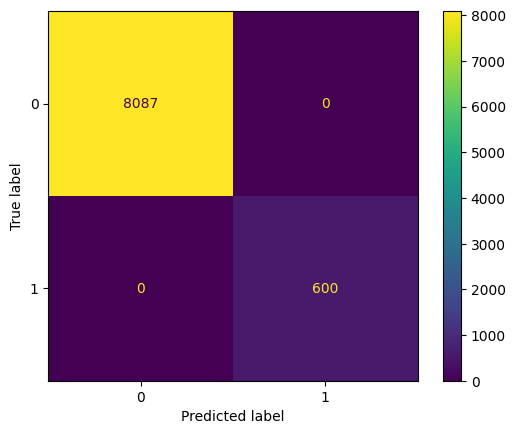

In [130]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rfc , X_test , y_test)

### Conclusion of CabCancellation:

- In this project, we successfully built a machine learning solution to predict whether a cab booking would be canceled or not. By analyzing various features such as travel type, booking method, vehicle model, and time-related features, we identified the key factors contributing to cab cancellations.

- Time difference factor ->As, above we have seen , the time differnce factor when the cab is booked and arrived affects the CabCancellation.

- Vehicle Model ID = 12 had a high representation and played a role in predicting cancellations.

- Booking Mode: Online vs mobile bookings showed different cancellation patterns.

- Business Implications:

With this model, cab service providers can proactively manage resources, reduce losses, and improve customer satisfaction.

This model can be integrated into booking platforms to flag high-risk cancellations, enabling interventions like confirmation calls or advance payment options.